Supplementary Figure 4

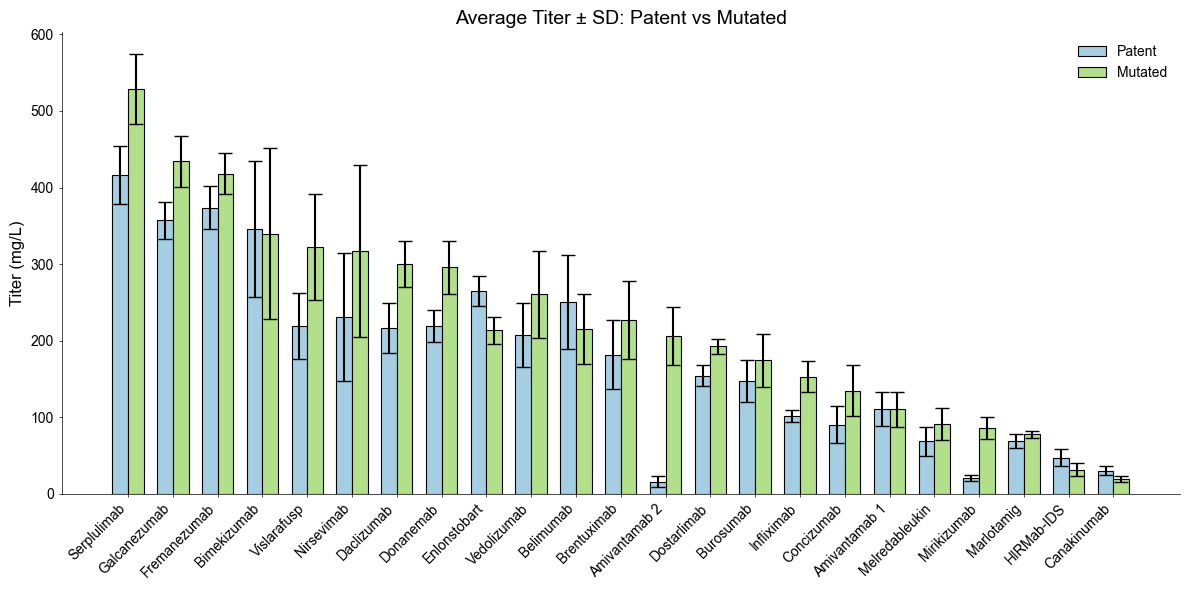

Titer columns used: ['Titer mg/L Rep 1', 'Titer mg/L Rep 2', 'Titer mg/L Rep 3']
   Base_Molecule  Patent_Mean  Patent_SD  Mutated_Mean  Mutated_SD
20   Serplulimab   416.238495  38.412255    528.510467   45.464378
13  Galcanezumab   356.964083  24.312621    434.114719   32.947781
12  Fremanezumab   373.672450  27.979786    418.112953   26.750330
3    Bimekizumab   345.958154  89.180962    339.852492  111.497950
22   Vislarafusp   218.870337  43.354192    322.343509   69.283866


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from IPython.display import display

# -----------------------------
# Load data
# -----------------------------
df = pd.read_excel("master-data.xlsx", engine="openpyxl")

# -----------------------------
# Required Molecule column
# -----------------------------
id_col = "Molecule"

if id_col not in df.columns:
    raise ValueError(
        f"Expected a '{id_col}' column, but it was not found. "
        f"Columns available: {list(df.columns)}"
    )

df = df.dropna(subset=[id_col]).copy()
df[id_col] = df[id_col].astype(str).str.strip()

# -----------------------------
# Parse base molecule name and variant
# Expects names ending in "Mutated" or "Patent"
# Example: "Amivantamab 1 Mutated" -> Base="Amivantamab 1", Variant="Mutated"
# -----------------------------
parsed = df[id_col].str.extract(r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$")

df["Base_Molecule"] = parsed["Base_Molecule"]
df["Variant"] = parsed["Variant"]

# Drop rows that do not match expected naming pattern
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

# -----------------------------
# Find titer replicate columns
# Matches: "Titer mg/L Rep 1", "Titer mg/L Rep 2", etc.
# -----------------------------
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

if len(titer_cols) == 0:
    raise ValueError(
        f"Could not find titer replicate columns.\n"
        f"Found titer_cols={titer_cols}\n"
        f"Check headers like 'Titer mg/L Rep 1'."
    )

# Sort columns by replicate number
def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

titer_cols = sorted(titer_cols, key=rep_num)

# -----------------------------
# Clean numeric columns
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": 0,
            "too low": 0,
            "TOO LOW": 0,
            "": np.nan,
            " ": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# -----------------------------
# Compute row-level mean and SD
# -----------------------------
df["Titer_Mean"] = df[titer_cols].mean(axis=1, skipna=True)
df["Titer_SD"] = df[titer_cols].std(axis=1, skipna=True)

# -----------------------------
# Aggregate in case there are duplicate Base_Molecule + Variant rows
# -----------------------------
summary_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(
          Titer_Mean=("Titer_Mean", "mean"),
          Titer_SD=("Titer_SD", "mean"),
          N_rows=("Titer_Mean", "size")
      )
      .reset_index()
)

# -----------------------------
# Pivot to wide format
# -----------------------------
mean_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Titer_Mean"
)

sd_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Titer_SD"
)

# Make sure both expected columns exist
for variant in ["Patent", "Mutated"]:
    if variant not in mean_wide.columns:
        mean_wide[variant] = np.nan
    if variant not in sd_wide.columns:
        sd_wide[variant] = np.nan

summary = pd.DataFrame({
    "Patent_Mean": mean_wide["Patent"],
    "Patent_SD": sd_wide["Patent"],
    "Mutated_Mean": mean_wide["Mutated"],
    "Mutated_SD": sd_wide["Mutated"]
}).reset_index()

# --------------------------------------------------
# Order molecules by MAX mean titer across Patent/Mutated
# --------------------------------------------------
summary["MaxMean"] = summary[["Patent_Mean", "Mutated_Mean"]].max(axis=1)
summary = summary.sort_values("MaxMean", ascending=False).drop(columns=["MaxMean"])

names = summary["Base_Molecule"].astype(str).tolist()
x = np.arange(len(names))
width = 0.35

# -----------------------------
# Plot settings
# -----------------------------
colors = {
    "Patent": "#A6CEE3",   # pastel blue
    "Mutated": "#B2DF8A"   # pastel green
}

fig, ax = plt.subplots(figsize=(12, 6))

# -----------------------------
# Plot bars
# -----------------------------
ax.bar(
    x - width / 2,
    summary["Patent_Mean"],
    width,
    yerr=summary["Patent_SD"],
    capsize=5,
    label="Patent",
    color=colors["Patent"],
    edgecolor="black",
    linewidth=0.8
)

ax.bar(
    x + width / 2,
    summary["Mutated_Mean"],
    width,
    yerr=summary["Mutated_SD"],
    capsize=5,
    label="Mutated",
    color=colors["Mutated"],
    edgecolor="black",
    linewidth=0.8
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_ylabel("Titer (mg/L)", fontsize=12)
ax.set_title("Average Titer ± SD: Patent vs Mutated", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Optional diagnostic printout
print("Titer columns used:", titer_cols)
print(summary.head())

Figure 4a.

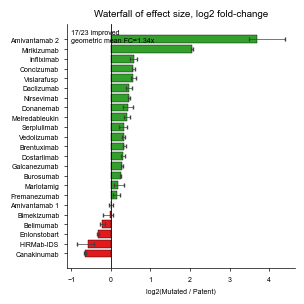

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =============================
# User-configurable settings
# =============================
INPUT_FILE = "master-data.xlsx"
ID_COL = "Molecule"

# Variant labels in the new file
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

# How to treat "Too Low"
TOO_LOW_AS = np.nan   # recommended; set to 0 only if you have a defined reason

# In this new file, Rep 1 Patent corresponds to Rep 1 Mutated after grouping by Base_Molecule
PAIRED_REPLICATES = True

# If you have an assay LLOQ, set it here, e.g. 1.0 mg/L. If None, pseudocount is data-derived.
ASSAY_LLOQ = None

# Output file
OUT_WATERFALL = "Figure_Waterfall_log2FC.svg"

# Plot styling
COLOR_POS = "#33a02c"
COLOR_NEG = "#e31a1c"

# Waterfall figure sizing
MM_TO_INCH = 1 / 25.4
WATERFALL_WIDTH_MM = 80
WATERFALL_HEIGHT_MM = 80
WATERFALL_FIGSIZE = (
    WATERFALL_WIDTH_MM * MM_TO_INCH,
    WATERFALL_HEIGHT_MM * MM_TO_INCH
)

# Waterfall font settings
WATERFALL_FONT = "Arial"
WATERFALL_TITLE_FONTSIZE = 7
WATERFALL_AXIS_FONTSIZE = 5
WATERFALL_TICK_FONTSIZE = 5
WATERFALL_TEXT_FONTSIZE = 5

# Keep SVG text editable rather than converting fonts to paths
plt.rcParams["svg.fonttype"] = "none"

# =============================
# Load / validate
# =============================
df = pd.read_excel(INPUT_FILE, engine="openpyxl")

if ID_COL not in df.columns:
    raise ValueError(f"Expected '{ID_COL}' column, but not found. Available: {list(df.columns)}")

df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

# =============================
# Parse Molecule into Base_Molecule and Variant
# =============================
parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# =============================
# Find replicate columns
# =============================
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

if len(titer_cols) == 0:
    raise ValueError(
        f"Could not find titer replicate columns.\n"
        f"Found titer_cols={titer_cols}\n"
        f"Expected headers like 'Titer mg/L Rep 1'."
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

titer_cols = sorted(titer_cols, key=rep_num)

# =============================
# Clean numeric columns
# =============================
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS,
            "too low": TOO_LOW_AS,
            "TOO LOW": TOO_LOW_AS,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# =============================
# Aggregate to one row per Base_Molecule + Variant
# =============================
df["Mean_row"] = df[titer_cols].mean(axis=1, skipna=True)

summary_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(
          Mean=("Mean_row", "mean"),
          N_rows=("Mean_row", "size")
      )
      .reset_index()
)

mean_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Mean"
)

for variant in [PARENT_LABEL, MUT_LABEL]:
    if variant not in mean_wide.columns:
        mean_wide[variant] = np.nan

summary = pd.DataFrame({
    "Base_Molecule": mean_wide.index,
    "Parental_Mean": mean_wide[PARENT_LABEL].values,
    "Mutated_Mean": mean_wide[MUT_LABEL].values
})

ID_SUMMARY_COL = "Base_Molecule"

# =============================
# Choose pseudocount epsilon
# =============================
if ASSAY_LLOQ is not None:
    eps = ASSAY_LLOQ / 2.0
else:
    min_pos = summary["Parental_Mean"].replace([0, np.inf, -np.inf], np.nan).dropna()
    min_pos = min_pos[min_pos > 0]
    eps = 0.01 * (min_pos.min() if len(min_pos) else 1.0)

summary["log2FC"] = np.log2(
    (summary["Mutated_Mean"] + eps) /
    (summary["Parental_Mean"] + eps)
)

# =============================
# Bootstrap CI for log2FC
# =============================
def bootstrap_ci(values, n_boot=5000, ci=95, seed=0):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    boots = []

    for _ in range(n_boot):
        samp = rng.choice(values, size=len(values), replace=True)
        boots.append(np.nanmedian(samp))

    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)

    return lo, hi

ci_rows = []

for name, g in df.groupby("Base_Molecule", dropna=False):

    patent_rows = g[g["Variant"] == PARENT_LABEL]
    mutated_rows = g[g["Variant"] == MUT_LABEL]

    if patent_rows.empty or mutated_rows.empty:
        ci_rows.append({
            "Base_Molecule": name,
            "log2FC_ci_low": np.nan,
            "log2FC_ci_high": np.nan
        })
        continue

    vals = []

    if PAIRED_REPLICATES:
        for _, prow in patent_rows.iterrows():
            for _, mrow in mutated_rows.iterrows():
                for c in titer_cols:
                    pv = prow[c]
                    mv = mrow[c]

                    if np.isfinite(pv) and np.isfinite(mv):
                        vals.append(np.log2((mv + eps) / (pv + eps)))

    else:
        pvals = patent_rows[titer_cols].values.flatten()
        mvals = mutated_rows[titer_cols].values.flatten()

        pvals = pvals[np.isfinite(pvals)]
        mvals = mvals[np.isfinite(mvals)]

        if len(pvals) > 0 and len(mvals) > 0:
            vals.append(np.log2((np.mean(mvals) + eps) / (np.mean(pvals) + eps)))

    lo, hi = bootstrap_ci(vals, n_boot=2000, ci=95, seed=0)

    ci_rows.append({
        "Base_Molecule": name,
        "log2FC_ci_low": lo,
        "log2FC_ci_high": hi
    })

ci_df = pd.DataFrame(ci_rows)
summary = summary.merge(ci_df, on="Base_Molecule", how="left")

# =============================
# Sort by effect
# =============================
summary_sorted = summary.sort_values("log2FC", ascending=False).reset_index(drop=True)

# ============================================================
# Horizontal waterfall plot, log2FC, saved as SVG
# ============================================================
fig2, ax2 = plt.subplots(figsize=WATERFALL_FIGSIZE)

names = summary_sorted[ID_SUMMARY_COL].astype(str).tolist()
vals = summary_sorted["log2FC"].values
ypos = np.arange(len(vals))

colors = np.where(vals >= 0, COLOR_POS, COLOR_NEG)

ax2.barh(
    ypos,
    vals,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

# Optional CI error bars
lo = summary_sorted["log2FC_ci_low"].values
hi = summary_sorted["log2FC_ci_high"].values

xerr_left = vals - lo
xerr_right = hi - vals

valid_err = (
    np.isfinite(vals) &
    np.isfinite(xerr_left) &
    np.isfinite(xerr_right) &
    (xerr_left >= 0) &
    (xerr_right >= 0)
)

if valid_err.any():
    ax2.errorbar(
        vals[valid_err],
        ypos[valid_err],
        xerr=[xerr_left[valid_err], xerr_right[valid_err]],
        fmt="none",
        ecolor="0.25",
        elinewidth=0.5,
        capsize=1.5
    )

ax2.axvline(0, color="k", lw=0.6)

ax2.set_yticks(ypos)
ax2.set_yticklabels(
    names,
    fontsize=WATERFALL_TICK_FONTSIZE,
    fontname=WATERFALL_FONT
)

ax2.invert_yaxis()

ax2.set_xlabel(
    f"log2({MUT_LABEL} / {PARENT_LABEL})",
    fontsize=WATERFALL_AXIS_FONTSIZE,
    fontname=WATERFALL_FONT
)

ax2.set_title(
    "Waterfall of effect size, log2 fold-change",
    fontsize=WATERFALL_TITLE_FONTSIZE,
    fontname=WATERFALL_FONT
)

n_improved = int(np.sum(vals > 0))
n_total = int(np.sum(np.isfinite(vals)))
geo_mean_fc = 2 ** np.nanmean(vals)

ax2.text(
    0.02,
    0.98,
    f"{n_improved}/{n_total} improved\ngeometric mean FC={geo_mean_fc:.2f}x",
    transform=ax2.transAxes,
    va="top",
    ha="left",
    fontsize=WATERFALL_TEXT_FONTSIZE,
    fontname=WATERFALL_FONT
)

ax2.tick_params(
    axis="both",
    which="major",
    labelsize=WATERFALL_TICK_FONTSIZE,
    width=0.5,
    length=2
)

for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontname(WATERFALL_FONT)
    label.set_fontsize(WATERFALL_TICK_FONTSIZE)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_linewidth(0.5)
ax2.spines["bottom"].set_linewidth(0.5)

plt.tight_layout()

fig2.savefig(
    OUT_WATERFALL,
    format="svg",
    bbox_inches="tight"
)

plt.show()

Figure 4a. Per Molecule Stats

In [16]:
import pandas as pd
import numpy as np
import re
from scipy.stats import ttest_rel

# If df is not already loaded, uncomment:
# df = pd.read_excel("codons-data-new.xlsx", engine="openpyxl")

id_col = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

if id_col not in df.columns:
    raise ValueError(f"Expected '{id_col}' column not found. Available columns: {list(df.columns)}")

df = df.dropna(subset=[id_col]).copy()
df[id_col] = df[id_col].astype(str).str.strip()

# ------------------------------------------------
# Parse Molecule into Base_Molecule and Variant
# Example:
# "Amivantamab 1 Patent"  -> Base_Molecule="Amivantamab 1", Variant="Patent"
# "Amivantamab 1 Mutated" -> Base_Molecule="Amivantamab 1", Variant="Mutated"
# ------------------------------------------------
parsed = df[id_col].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# ------------------------------------------------
# Find titer replicate columns robustly
# New format: "Titer mg/L Rep 1", "Titer mg/L Rep 2", etc.
# ------------------------------------------------
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

titer_cols = sorted(titer_cols, key=rep_num)

if len(titer_cols) < 2:
    raise ValueError(
        f"Not enough replicate titer columns to run paired t-test. "
        f"Found titer_cols={titer_cols}"
    )

# ------------------------------------------------
# Clean numeric
# Original script used Too Low -> 0
# If you prefer censoring missing/low values, change 0 to np.nan
# ------------------------------------------------
def clean_numeric(s):
    return pd.to_numeric(
        s.replace({
            "Too Low": 0,
            "too low": 0,
            "TOO LOW": 0,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# ------------------------------------------------
# Paired t-test per Base_Molecule
# Patent Rep 1 is paired with Mutated Rep 1, etc.
# ------------------------------------------------
results = []

for mol, sub in df.groupby("Base_Molecule", dropna=False):

    patent_rows = sub[sub["Variant"] == PARENT_LABEL]
    mutated_rows = sub[sub["Variant"] == MUT_LABEL]

    # Need both Patent and Mutated rows
    if patent_rows.empty or mutated_rows.empty:
        continue

    pairs_parent = []
    pairs_mut = []

    # Usually there is one Patent row and one Mutated row per Base_Molecule.
    # If duplicates exist, this uses all row combinations.
    for _, prow in patent_rows.iterrows():
        for _, mrow in mutated_rows.iterrows():
            for c in titer_cols:
                pv = prow[c]
                mv = mrow[c]

                if np.isfinite(pv) and np.isfinite(mv):
                    pairs_parent.append(pv)
                    pairs_mut.append(mv)

    parental = np.array(pairs_parent, dtype=float)
    mutated = np.array(pairs_mut, dtype=float)

    n_pairs = len(parental)

    # Need at least 2 paired observations for paired t-test
    if n_pairs < 2:
        continue

    tstat, pval = ttest_rel(mutated, parental, nan_policy="omit")

    parental_mean = float(np.mean(parental))
    mutated_mean = float(np.mean(mutated))

    results.append({
        "Base_Molecule": mol,
        "N_pairs": n_pairs,
        "Patent_Mean": parental_mean,
        "Mutated_Mean": mutated_mean,
        "Mutated_Higher": mutated_mean > parental_mean,
        "Mean_Difference": mutated_mean - parental_mean,
        "Fold_Change": mutated_mean / parental_mean if parental_mean != 0 else np.nan,
        "log2FC": np.log2(mutated_mean / parental_mean) if parental_mean > 0 and mutated_mean > 0 else np.nan,
        "t_stat": float(tstat),
        "p_value": float(pval)
    })

results_df = (
    pd.DataFrame(results)
      .sort_values("p_value")
      .reset_index(drop=True)
)

results_df

summary_table = pd.DataFrame({
    "Metric": [
        "Total molecules tested",
        "Mutated mean > Patent mean",
        "Mutated higher AND p < 0.05"
    ],
    "Count": [
        len(results_df),
        int(results_df["Mutated_Higher"].sum()),
        int(((results_df["Mutated_Higher"]) & (results_df["p_value"] < 0.05)).sum())
    ]
})

summary_table

,Metric,Count
0,Total molecules tested,23
1,Mutated mean > Patent mean,17
2,Mutated higher AND p < 0.05,15


Figure 4a. Overall Stats

In [17]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np
import pandas as pd
import re

# ------------------------------------
# Assumes df is already loaded:
# df = pd.read_excel("codons-data-new.xlsx", engine="openpyxl")
# ------------------------------------

id_col = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

if id_col not in df.columns:
    raise ValueError(f"Expected '{id_col}' column not found in df. Available columns: {list(df.columns)}")

df = df.dropna(subset=[id_col]).copy()
df[id_col] = df[id_col].astype(str).str.strip()

# ------------------------------------
# Parse Molecule into Base_Molecule and Variant
# Example:
# "Amivantamab 1 Patent"  -> Base_Molecule="Amivantamab 1", Variant="Patent"
# "Amivantamab 1 Mutated" -> Base_Molecule="Amivantamab 1", Variant="Mutated"
# ------------------------------------
parsed = df[id_col].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# ------------------------------------
# Find titer replicate columns
# New format: "Titer mg/L Rep 1", "Titer mg/L Rep 2", etc.
# ------------------------------------
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else None

titer_cols = sorted(titer_cols, key=lambda c: rep_num(c) if rep_num(c) is not None else 999)

if len(titer_cols) == 0:
    raise ValueError(
        f"No titer replicate columns found. Expected headers like 'Titer mg/L Rep 1'. "
        f"Available columns: {list(df.columns)}"
    )

# ------------------------------------
# Clean replicate columns
# Original script used Too Low -> 0.
# Change 0 to np.nan if you want to censor low values instead.
# ------------------------------------
def clean_numeric(s):
    return pd.to_numeric(
        s.replace({
            "Too Low": 0,
            "too low": 0,
            "TOO LOW": 0,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# ------------------------------------
# Convert to long format:
# one row per Base_Molecule / Variant / Replicate
# ------------------------------------
long_df = df.melt(
    id_vars=["Base_Molecule", "Variant"],
    value_vars=titer_cols,
    var_name="Replicate_Column",
    value_name="Titer"
)

long_df["Replicate"] = long_df["Replicate_Column"].apply(rep_num)
long_df = long_df.dropna(subset=["Titer", "Replicate"]).copy()
long_df["Replicate"] = long_df["Replicate"].astype(int)

# ------------------------------------
# If duplicate rows exist for same Base_Molecule / Variant / Replicate,
# average them so each pair is represented once.
# ------------------------------------
long_summary = (
    long_df.groupby(["Base_Molecule", "Variant", "Replicate"], dropna=False)
           .agg(Titer=("Titer", "mean"))
           .reset_index()
)

# ------------------------------------
# Pivot Patent and Mutated side-by-side
# ------------------------------------
paired_df = (
    long_summary.pivot_table(
        index=["Base_Molecule", "Replicate"],
        columns="Variant",
        values="Titer",
        aggfunc="mean"
    )
    .reset_index()
)

# Require both Patent and Mutated columns
for label in [PARENT_LABEL, MUT_LABEL]:
    if label not in paired_df.columns:
        raise ValueError(
            f"Expected variant '{label}' not found after parsing/pivoting. "
            f"Variants found: {list(long_summary['Variant'].dropna().unique())}"
        )

# Keep only valid pairs
paired_df = paired_df[
    pd.notna(paired_df[PARENT_LABEL]) &
    pd.notna(paired_df[MUT_LABEL])
].copy()

paired_df["Delta"] = paired_df[MUT_LABEL] - paired_df[PARENT_LABEL]

# Rename columns for clarity
paired_df = paired_df.rename(columns={
    PARENT_LABEL: "Patent",
    MUT_LABEL: "Mutated"
})

# ------------------------------------
# Summary statistics
# ------------------------------------
n_pairs = len(paired_df)

if n_pairs == 0:
    raise ValueError("No valid paired replicate observations found after cleaning/filtering.")

mean_patent = paired_df["Patent"].mean()
mean_mutated = paired_df["Mutated"].mean()
mean_delta = paired_df["Delta"].mean()

# ------------------------------------
# Statistical tests: global across all paired replicates
# ------------------------------------
# Paired t-test
t_stat, t_pval = ttest_rel(paired_df["Mutated"], paired_df["Patent"])

# Wilcoxon signed-rank test
# Wilcoxon can fail if all deltas are zero or too few non-zero differences.
nonzero_mask = paired_df["Delta"] != 0

if nonzero_mask.sum() < 1:
    w_stat, w_pval = np.nan, np.nan
else:
    w_stat, w_pval = wilcoxon(
        paired_df.loc[nonzero_mask, "Mutated"],
        paired_df.loc[nonzero_mask, "Patent"],
        zero_method="wilcox"
    )

# ------------------------------------
# Results table
# ------------------------------------
results_summary = pd.DataFrame({
    "Metric": [
        "Number of paired replicates",
        "Mean Patent titer (mg/L)",
        "Mean Mutated titer (mg/L)",
        "Mean Δ (Mutated − Patent)",
        "Paired t-test p-value",
        "Wilcoxon signed-rank p-value",
        "Mutated better on average?"
    ],
    "Value": [
        int(n_pairs),
        float(mean_patent),
        float(mean_mutated),
        float(mean_delta),
        float(t_pval),
        float(w_pval) if pd.notna(w_pval) else np.nan,
        "Yes" if mean_delta > 0 else "No"
    ]
})

paired_df, results_summary

(Variant  Base_Molecule  Replicate     Mutated      Patent       Delta
 0        Amivantamab 1          1  119.629062  114.207233    5.421829
 1        Amivantamab 1          2  127.493708  131.665848   -4.172140
 2        Amivantamab 1          3   84.088073   86.649860   -2.561787
 3        Amivantamab 2          1  219.651804   19.336145  200.315659
 4        Amivantamab 2          2  235.728373   20.420748  215.307625
 ..                 ...        ...         ...         ...         ...
 64         Vedolizumab          2  194.354372  158.729408   35.624964
 65         Vedolizumab          3  288.554126  227.808550   60.745576
 66         Vislarafusp          1  373.395486  257.718968  115.676518
 67         Vislarafusp          2  243.474050  172.102396   71.371654
 68         Vislarafusp          3  350.160991  226.789648  123.371343
 
 [69 rows x 5 columns],
                          Metric       Value
 0   Number of paired replicates          69
 1      Mean Patent titer (mg/L)

Supplementary Figure 5

Experimental molecules: 23
Scored therapeutics: 23
Merged molecules: 23

Chain groups:
Chain_Group
Heavy    23
Light    23
Name: Therapeutic, dtype: int64

Available plot-value columns:
['Titer_PlotValue']


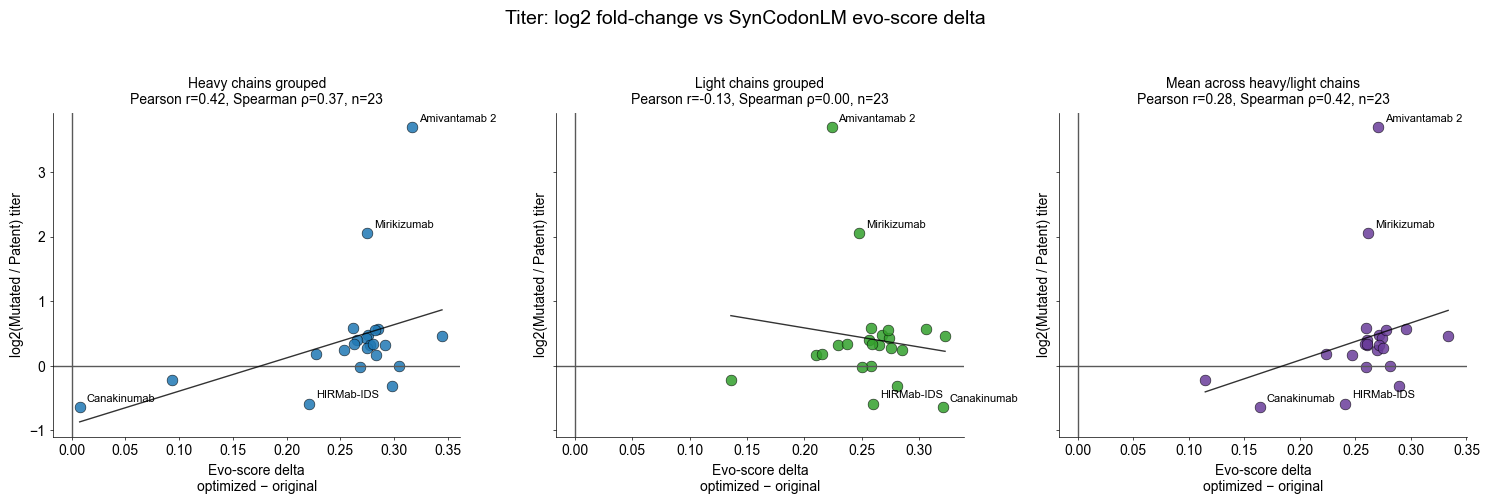

In [18]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# -----------------------------
# Input files
# -----------------------------
DATA_FILE = "master-data.xlsx"
SCORE_FILE = "patented+mutated-sequences-with-evo-scores.xlsx"

# -----------------------------
# User settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

TOO_LOW_AS = np.nan

# Evo score choice
# Positive values mean optimized sequence scored better than original.
ORIG_SCORE_COL = "Original_DNA_synonym_constrained_mean_logprob"
OPT_SCORE_COL  = "Optimized_DNA_synonym_constrained_mean_logprob"


METRICS_TO_PLOT = {
    "Titer": {
        "mode": "pattern",
        "pattern": r"^Titer\s*mg/L\s*Rep\s*\d+$",
        "transform": "log2fc",
        "ylabel": f"log2({MUT_LABEL} / {PARENT_LABEL}) titer",
        "neutral": 0,
    }
}

COLOR_HEAVY = "#1f78b4"
COLOR_LIGHT = "#33a02c"
COLOR_MEAN = "#6a3d9a"

# -----------------------------
# Helper functions
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS,
            "too low": TOO_LOW_AS,
            "TOO LOW": TOO_LOW_AS,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_name):
    chain_name = str(chain_name).strip().lower()
    if chain_name.startswith("heavy"):
        return "Heavy"
    elif chain_name.startswith("light"):
        return "Light"
    else:
        return "Other"

def plot_panel(ax, data, x_col, y_col, title, color, y_label, neutral=0):
    d = data[[x_col, y_col, "Therapeutic"]].replace([np.inf, -np.inf], np.nan).dropna()

    ax.scatter(
        d[x_col],
        d[y_col],
        s=60,
        color=color,
        edgecolor="black",
        linewidth=0.4,
        alpha=0.85
    )

    ax.axvline(0, color="0.35", lw=1)
    ax.axhline(neutral, color="0.35", lw=1)

    # Trend line
    if len(d) >= 3 and d[x_col].nunique() > 1:
        slope, intercept = np.polyfit(d[x_col], d[y_col], 1)
        xs = np.linspace(d[x_col].min(), d[x_col].max(), 100)
        ax.plot(xs, slope * xs + intercept, color="black", lw=1, alpha=0.8)

    pearson_r = d[x_col].corr(d[y_col], method="pearson") if len(d) >= 3 else np.nan
    spearman_r = d[x_col].corr(d[y_col], method="spearman") if len(d) >= 3 else np.nan

    ax.set_title(
        f"{title}\nPearson r={pearson_r:.2f}, Spearman ρ={spearman_r:.2f}, n={len(d)}",
        fontsize=10
    )

    ax.set_xlabel("Evo-score delta\noptimized − original")
    ax.set_ylabel(y_label)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Label strongest deviations from neutral
    label_df = d.reindex((d[y_col] - neutral).abs().sort_values(ascending=False).head(4).index)

    for _, r in label_df.iterrows():
        ax.annotate(
            r["Therapeutic"],
            (r[x_col], r[y_col]),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=8
        )

# -----------------------------
# Load and parse experimental data
# -----------------------------
df = pd.read_excel(DATA_FILE, engine="openpyxl")

df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

# -----------------------------
# Build metric summary table
# -----------------------------
all_metric_wides = []

for metric_name, cfg in METRICS_TO_PLOT.items():

    if cfg["mode"] == "pattern":
        metric_cols = [
            c for c in df.columns
            if re.match(cfg["pattern"], str(c).strip(), re.IGNORECASE)
        ]
        metric_cols = sorted(metric_cols, key=rep_num)

        if len(metric_cols) == 0:
            print(f"Skipping {metric_name}: no columns matched pattern {cfg['pattern']}")
            continue

        for c in metric_cols:
            df[c] = clean_numeric(df[c])

        df[f"{metric_name}_Mean_row"] = df[metric_cols].mean(axis=1, skipna=True)

    elif cfg["mode"] == "direct":
        metric_col = cfg["column"]

        if metric_col not in df.columns:
            print(f"Skipping {metric_name}: column not found: {metric_col}")
            continue

        df[metric_col] = clean_numeric(df[metric_col])
        df[f"{metric_name}_Mean_row"] = df[metric_col]

    else:
        raise ValueError(f"Unknown metric mode for {metric_name}: {cfg['mode']}")

    long = (
        df.groupby(["Base_Molecule", "Variant"], dropna=False)
          .agg(Metric_Mean=(f"{metric_name}_Mean_row", "mean"))
          .reset_index()
    )

    wide = long.pivot(
        index="Base_Molecule",
        columns="Variant",
        values="Metric_Mean"
    ).reset_index()

    for v in [PARENT_LABEL, MUT_LABEL]:
        if v not in wide.columns:
            wide[v] = np.nan

    wide[f"{metric_name}_Patent_Mean"] = wide[PARENT_LABEL]
    wide[f"{metric_name}_Mutated_Mean"] = wide[MUT_LABEL]

    if cfg["transform"] == "log2fc":
        all_positive = wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
        all_positive = all_positive[np.isfinite(all_positive) & (all_positive > 0)]
        eps = 0.01 * np.min(all_positive) if len(all_positive) else 1e-6

        wide[f"{metric_name}_PlotValue"] = np.log2(
            (wide[MUT_LABEL] + eps) /
            (wide[PARENT_LABEL] + eps)
        )

    elif cfg["transform"] == "delta":
        wide[f"{metric_name}_PlotValue"] = wide[MUT_LABEL] - wide[PARENT_LABEL]

    else:
        raise ValueError(f"Unknown transform for {metric_name}: {cfg['transform']}")

    keep = wide[[
        "Base_Molecule",
        f"{metric_name}_Patent_Mean",
        f"{metric_name}_Mutated_Mean",
        f"{metric_name}_PlotValue"
    ]].copy()

    all_metric_wides.append(keep)

# Merge all metric summaries
summary = None
for mdf in all_metric_wides:
    if summary is None:
        summary = mdf.copy()
    else:
        summary = summary.merge(mdf, on="Base_Molecule", how="outer")

summary = summary.rename(columns={"Base_Molecule": "Therapeutic"})

# -----------------------------
# Load SynCodonLM score data
# -----------------------------
score_df = pd.read_excel(
    SCORE_FILE,
    sheet_name="Scored_Sequences",
    engine="openpyxl"
)

score_df["Therapeutic"] = score_df["Therapeutic"].astype(str).str.strip()
score_df["Chain"] = score_df["Chain"].astype(str).str.strip()
score_df["Chain_Group"] = score_df["Chain"].apply(get_chain_group)

for c in [ORIG_SCORE_COL, OPT_SCORE_COL]:
    score_df[c] = pd.to_numeric(score_df[c], errors="coerce")

score_df["Evo_Score_Delta"] = score_df[OPT_SCORE_COL] - score_df[ORIG_SCORE_COL]

# Keep Heavy and Light only
score_df = score_df[score_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

# Average Heavy 1/Heavy 2 together and Light 1/Light 2 together
score_grouped = (
    score_df.groupby(["Therapeutic", "Chain_Group"], dropna=False)
            .agg(
                Evo_Score_Delta=("Evo_Score_Delta", "mean"),
                N_Chains=("Evo_Score_Delta", "count")
            )
            .reset_index()
)

# Mean across all available heavy/light chains per molecule
score_mean = (
    score_df.groupby("Therapeutic", dropna=False)
            .agg(
                Mean_Evo_Score_Delta=("Evo_Score_Delta", "mean"),
                N_Chains_Total=("Evo_Score_Delta", "count")
            )
            .reset_index()
)

# Merge experimental metrics with evo scores
merged_grouped = score_grouped.merge(summary, on="Therapeutic", how="inner")
merged_mean = score_mean.merge(summary, on="Therapeutic", how="inner")

# -----------------------------
# QC
# -----------------------------
print("Experimental molecules:", summary["Therapeutic"].nunique())
print("Scored therapeutics:", score_df["Therapeutic"].nunique())
print("Merged molecules:", merged_mean["Therapeutic"].nunique())

print("\nChain groups:")
print(score_grouped.groupby("Chain_Group")["Therapeutic"].nunique())

print("\nAvailable plot-value columns:")
print([c for c in summary.columns if c.endswith("_PlotValue")])

# -----------------------------
# Make the Titer figure (show only, do not save)
# -----------------------------
for metric_name, cfg in METRICS_TO_PLOT.items():

    y_col = f"{metric_name}_PlotValue"

    if y_col not in summary.columns:
        print(f"Skipping figure for {metric_name}: {y_col} not found.")
        continue

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(15, 4.8),
        sharey=True
    )

    # Heavy panel
    heavy_df = merged_grouped[merged_grouped["Chain_Group"] == "Heavy"].copy()
    plot_panel(
        ax=axes[0],
        data=heavy_df,
        x_col="Evo_Score_Delta",
        y_col=y_col,
        title="Heavy chains grouped",
        color=COLOR_HEAVY,
        y_label=cfg["ylabel"],
        neutral=cfg["neutral"]
    )

    # Light panel
    light_df = merged_grouped[merged_grouped["Chain_Group"] == "Light"].copy()
    plot_panel(
        ax=axes[1],
        data=light_df,
        x_col="Evo_Score_Delta",
        y_col=y_col,
        title="Light chains grouped",
        color=COLOR_LIGHT,
        y_label=cfg["ylabel"],
        neutral=cfg["neutral"]
    )

    # Mean all chains panel
    mean_plot_df = merged_mean.rename(
        columns={"Mean_Evo_Score_Delta": "Evo_Score_Delta"}
    )

    plot_panel(
        ax=axes[2],
        data=mean_plot_df,
        x_col="Evo_Score_Delta",
        y_col=y_col,
        title="Mean across heavy/light chains",
        color=COLOR_MEAN,
        y_label=cfg["ylabel"],
        neutral=cfg["neutral"]
    )

    if cfg["transform"] == "log2fc":
        title_transform = "log2 fold-change"
    else:
        title_transform = "raw delta"

    fig.suptitle(
        f"{metric_name}: {title_transform} vs SynCodonLM evo-score delta",
        fontsize=14,
        y=1.04
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Preview table
# -----------------------------
preview_cols = [
    "Therapeutic",
    "Mean_Evo_Score_Delta",
    "N_Chains_Total"
] + [c for c in summary.columns if c.endswith("_PlotValue")]



Figure 4b.

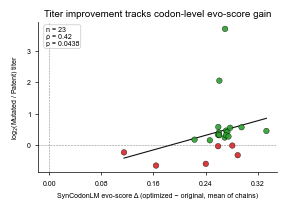

Saved: Figure_Titer_log2FC_vs_EvoDelta_MeanChains_Spearman.svg
Molecules plotted: 23
Spearman rho = 0.4239
Spearman p   = 0.04382


In [19]:
# ============================================================
#   Titer log2FC vs mean-across-chains SynCodonLM evo-score delta
#   Reports Spearman rho and p-value
#
# Saves as editable SVG for Illustrator.
# Requires `merged_mean` and `summary` to already exist.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import stats

# ---------- Style ----------
MM_TO_INCH = 1 / 25.4
FIG_W_MM, FIG_H_MM = 70, 50
FIGSIZE = (FIG_W_MM * MM_TO_INCH, FIG_H_MM * MM_TO_INCH)

FONT = "Arial"

TITLE_FS = 7
AXIS_FS  = 5
TICK_FS  = 5
STAT_FS  = 5

# Green / red by titer direction
COLOR_UP   = "#2ca02c"
COLOR_DOWN = "#d62728"

FIT_COLOR   = "#111111"
GUIDE_COLOR = "0.55"

OUT_SVG = "Figure_Titer_log2FC_vs_EvoDelta_MeanChains_Spearman.svg"

plt.rcParams.update({
    "svg.fonttype": "none",      # keep text editable in Illustrator
    "pdf.fonttype": 42,
    "font.family": FONT,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
})

# ---------- Data ----------
y_col = "Titer_PlotValue"

plot_df = (
    merged_mean
    .rename(columns={"Mean_Evo_Score_Delta": "Evo_Score_Delta"})
    [["Therapeutic", "Evo_Score_Delta", y_col]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

x = plot_df["Evo_Score_Delta"].to_numpy()
y = plot_df[y_col].to_numpy()

n = len(plot_df)

# ---------- Statistics ----------

# Linear regression retained only for plotting the fit line
slope, intercept, r_lin, p_lin, se = stats.linregress(x, y)

# Spearman rank correlation
rho, p_s = stats.spearmanr(x, y)

# Fit line
x_grid = np.linspace(x.min(), x.max(), 200)
y_hat = slope * x_grid + intercept

# Point colors by titer direction
point_colors = np.where(y > 0, COLOR_UP, COLOR_DOWN)

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=FIGSIZE)

# Zero guides
ax.axvline(0, color=GUIDE_COLOR, lw=0.4, ls="--", zorder=0)
ax.axhline(0, color=GUIDE_COLOR, lw=0.4, ls="--", zorder=0)

# Linear fit line
ax.plot(
    x_grid,
    y_hat,
    color=FIT_COLOR,
    lw=0.8,
    zorder=2
)

# Scatter points
ax.scatter(
    x,
    y,
    s=16,
    c=point_colors,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9,
    zorder=3
)

# ---------- Labels ----------
ax.set_xlabel(
    "SynCodonLM evo-score Δ (optimized − original, mean of chains)",
    fontsize=AXIS_FS,
    fontname=FONT
)

ax.set_ylabel(
    f"log$_2$({MUT_LABEL} / {PARENT_LABEL}) titer",
    fontsize=AXIS_FS,
    fontname=FONT
)

ax.set_title(
    "Titer improvement tracks codon-level evo-score gain",
    fontsize=TITLE_FS,
    fontname=FONT,
    pad=4
)

# ---------- Ticks ----------
ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_FS
)

ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

for lab in ax.get_xticklabels() + ax.get_yticklabels():
    lab.set_fontname(FONT)

# ---------- Cleanup ----------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------- Stats box ----------
def fmt_p(p):
    return "p < 0.001" if p < 1e-3 else f"p = {p:.3g}"

stats_txt = (
    f"n = {n}\n"
    f"ρ = {rho:.2f}\n"
    f"{fmt_p(p_s)}"
)

ax.text(
    0.03,
    0.97,
    stats_txt,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=STAT_FS,
    fontname=FONT,
    bbox=dict(
        boxstyle="round,pad=0.25",
        fc="white",
        ec="0.7",
        lw=0.4,
        alpha=0.9
    )
)

plt.tight_layout(pad=0.3)

fig.savefig(
    OUT_SVG,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("Saved:", OUT_SVG)
print(f"Molecules plotted: {n}")
print(f"Spearman rho = {rho:.4f}")
print(f"Spearman p   = {p_s:.4g}")


Figure 4c.

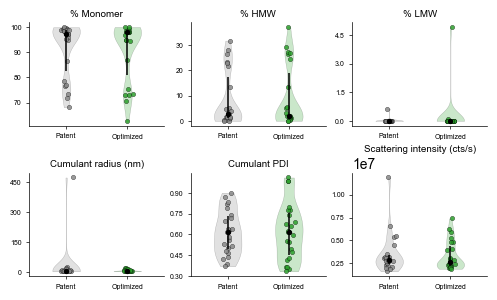

Saved: Figure_QualityAttributes_Violins.svg


In [20]:
# ============================================================
# Multipanel figure: Patent vs Optimized violin plots
# One SVG, 6 panels (ungroup in Illustrator)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

XLSX = "master-data.xlsx"
OUT_SVG = "Figure_QualityAttributes_Violins.svg"

# ---------- Style ----------
MM_TO_INCH = 1 / 25.4
PANEL_W_MM, PANEL_H_MM = 38, 32
NCOLS, NROWS = 3, 2
FIG_W_MM = PANEL_W_MM * NCOLS + 10
FIG_H_MM = PANEL_H_MM * NROWS + 10
FIGSIZE = (FIG_W_MM * MM_TO_INCH, FIG_H_MM * MM_TO_INCH)

FONT = "Arial"
TITLE_FS = 7
AXIS_FS  = 5
TICK_FS  = 5

COLOR_PAT = "#888888"
COLOR_OPT = "#2ca02c"

plt.rcParams.update({
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "font.family":  FONT,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
})

# ---------- Metrics ----------
metrics = [
    ("% Monomer",                    ["% Monomer Rep 1", "% Monomer Rep 2", "% Monomer Rep 3"], +1),
    ("% HMW",                        ["% HMW Rep 1", "% HMW Rep 2", "% HMW Rep 3"],             -1),
    ("% LMW",                        ["% LMW Rep 1", "% LMW Rep 2", "% LMW Rep 3"],             -1),
    ("Cumulant radius (nm)",         ["Cumulant Radius (nm) mean"],                             -1),
    ("Cumulant PDI",                 ["Cumulant PDI mean"],                                     -1),
    ("Scattering intensity (cts/s)", ["Scattering Intensity (cts/s) mean"],                     -1),
]

# ---------- Load & split ----------
df = pd.read_excel(XLSX, engine="openpyxl")

def split_name(m):
    m = str(m).strip()
    if m.endswith(" Mutated"):
        return m[:-8], "Mutated"
    if m.endswith(" Patent"):
        return m[:-7], "Patent"
    return m, np.nan

df[["Base", "Condition"]] = df["Molecule"].apply(lambda x: pd.Series(split_name(x)))

def per_mol(df, cols):
    d = df.copy()
    for c in cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d["_v"] = d[cols].mean(axis=1, skipna=True)
    out = {}
    for base, sub in d.groupby("Base"):
        v = {}
        for cond in ["Patent", "Mutated"]:
            r = sub[sub["Condition"] == cond]
            if len(r) == 1:
                v[cond] = r["_v"].iloc[0]
        if len(v) == 2 and np.isfinite(v["Patent"]) and np.isfinite(v["Mutated"]):
            out[base] = v
    return out


# ---------- Figure ----------
fig, axes = plt.subplots(NROWS, NCOLS, figsize=FIGSIZE)
axes = axes.flatten()

rng = np.random.default_rng(42)

for ax, (name, cols, better_dir) in zip(axes, metrics):

    v = per_mol(df, cols)

    bases = sorted(v.keys())

    p_arr = np.array([v[b]["Patent"]  for b in bases], dtype=float)
    m_arr = np.array([v[b]["Mutated"] for b in bases], dtype=float)

    data = [p_arr, m_arr]
    positions = [0, 1]
    colors = [COLOR_PAT, COLOR_OPT]

    # Background violin
    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.45,
        bw_method=0.4,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body, c in zip(parts["bodies"], colors):
        body.set_facecolor(c)
        body.set_edgecolor("black")
        body.set_linewidth(0.3)
        body.set_alpha(0.25)

    # Jittered points
    for pos, arr, color in zip(positions, data, colors):

        jitter = rng.normal(0, 0.04, len(arr))

        ax.scatter(
            np.full(len(arr), pos) + jitter,
            arr,
            s=10,
            color=color,
            edgecolor="black",
            linewidth=0.25,
            alpha=0.85,
            zorder=4
        )

        # Quartiles + median
        q1, med, q3 = np.percentile(arr, [25, 50, 75])

        ax.vlines(
            pos,
            q1,
            q3,
            color="black",
            lw=1.1,
            zorder=5
        )

        ax.scatter(
            pos,
            med,
            color="black",
            s=8,
            zorder=6
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Patent", "Optimized"], fontsize=TICK_FS)

    ax.set_xlim(-0.6, 1.6)

    ax.set_title(
        name,
        fontsize=TITLE_FS,
        pad=4
    )

    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for extra_ax in axes[len(metrics):]:
    extra_ax.axis("off")

plt.tight_layout(pad=0.4)

fig.savefig(
    OUT_SVG,
    format="svg",
    bbox_inches="tight"
)

plt.show()
print("Saved:", OUT_SVG)


Figure 4c Significance Statistics

In [21]:
from scipy.stats import ttest_rel, wilcoxon
import pandas as pd
import numpy as np

results = []

for name, cols, better_dir in metrics:

    v = per_mol(df, cols)
    bases = sorted(v.keys())

    patent = np.array([v[b]["Patent"] for b in bases], dtype=float)
    optimized = np.array([v[b]["Mutated"] for b in bases], dtype=float)

    delta = optimized - patent

    # Paired t-test
    t_stat, t_p = ttest_rel(optimized, patent)

    # Wilcoxon signed-rank
    nz = delta != 0
    if nz.sum() > 0:
        w_stat, w_p = wilcoxon(
            optimized[nz],
            patent[nz],
            zero_method="wilcox"
        )
    else:
        w_stat, w_p = np.nan, np.nan

    # Directionality
    if better_dir == 1:
        improvement_pct = 100 * np.mean(delta > 0)
    else:
        improvement_pct = 100 * np.mean(delta < 0)

    results.append({
        "Metric": name,
        "N molecules": len(patent),
        "Mean Patent": np.mean(patent),
        "Mean Optimized": np.mean(optimized),
        "Mean Δ": np.mean(delta),
        "Median Δ": np.median(delta),
        "Paired t-test p": t_p,
        "Wilcoxon p": w_p,
        "% Improved": improvement_pct
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
from statsmodels.stats.multitest import multipletests

results_df["BH-adjusted p"] = multipletests(
    results_df["Wilcoxon p"],
    method="fdr_bh"
)[1]

display(results_df)

print(
    results_df[
        ["Metric",
         "N molecules",
         "Mean Δ",
         "Paired t-test p",
         "Wilcoxon p",
         "BH-adjusted p"]
    ]
)

,Metric,N molecules,Mean Patent,Mean Optimized,Mean Δ,Median Δ,Paired t-test p,Wilcoxon p,% Improved,BH-adjusted p
0,% Monomer,23,9.133891e+01,9.038638e+01,-0.952536,-0.551667,0.063984,0.065036,34.782609,0.240608
1,% HMW,23,8.631667e+00,9.393478e+00,0.761812,0.356667,0.105729,0.080203,30.434783,0.240608
2,% LMW,23,2.927536e-02,2.192754e-01,0.190000,0.000000,0.388693,0.652344,17.391304,0.893212
3,Cumulant radius (nm),23,2.756525e+01,7.549105e+00,-20.016141,-0.191418,0.335976,0.893212,56.521739,0.893212
4,Cumulant PDI,23,6.154388e-01,6.197733e-01,0.004334,-0.010325,0.927901,0.799773,52.173913,0.893212
5,Scattering intensity (cts/s),23,3.543878e+06,3.407212e+06,-136666.484869,-138485.079267,0.734513,0.893212,52.173913,0.893212


                         Metric  N molecules         Mean Δ  Paired t-test p  \
0                     % Monomer           23      -0.952536         0.063984   
1                         % HMW           23       0.761812         0.105729   
2                         % LMW           23       0.190000         0.388693   
3          Cumulant radius (nm)           23     -20.016141         0.335976   
4                  Cumulant PDI           23       0.004334         0.927901   
5  Scattering intensity (cts/s)           23 -136666.484869         0.734513   

   Wilcoxon p  BH-adjusted p  
0    0.065036       0.240608  
1    0.080203       0.240608  
2    0.652344       0.893212  
3    0.893212       0.893212  
4    0.799773       0.893212  
5    0.893212       0.893212  
